# 02a: Explore canonical telemetry

Read-only, DuckDB-backed exploration. 

Queries are filtered and capped before data reaches pandas. Nothing is written.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'src' / 'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import canonical_output_path, duplicate_audit_path
from ausgrid_analysis.metadata import metadata_output_path
from ausgrid_analysis.schemas import sql_string

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Select a bounded slice

Edit these values freely. `SERIAL=None` chooses a site from the selected month. `MAX_ROWS` is a hard guardrail.

In [2]:
CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
MONTH = '2024-09'
SERIAL = None
DATE_FROM = None  # local date, e.g. '2025-04-10'
DATE_TO = None    # local date, exclusive
PHASES = ['A', 'B', 'C']
MAX_ROWS = 100_000

config = load_config(CONFIG_PATH, check_inputs=False)
full_scope = config.scope(None, None)
canonical_dir = canonical_output_path(config, full_scope)
assert canonical_dir.is_dir(), f'Run notebook 01 first: {canonical_dir}'
canonical_glob = str(canonical_dir / '**' / '*.parquet')
con = duckdb.connect()
con.execute(f"SET memory_limit='{config.processing.memory_limit}'")
con.execute(f"SET threads={min(config.processing.threads, 4)}")
con.execute("SET TimeZone='UTC'")
con.execute(f"CREATE VIEW canonical AS SELECT * FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning=true)")
print('Canonical source:', canonical_dir)

Canonical source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\canonical_phase


In [3]:
year, month = map(int, MONTH.split('-'))
overview = con.execute('''
    SELECT count(*) n_rows, count(DISTINCT serial) n_sites,
           min(timestamp_local) first_local, max(timestamp_local) last_local,
           count_if(NOT voltage_physical_ok) invalid_voltage_rows,
           count_if(p_export_w IS NULL) null_p_rows,
           count_if(q_absorbing_var IS NULL) null_q_rows,
           count_if(NOT metadata_available) rows_without_metadata
    FROM canonical WHERE year_utc=? AND month_utc=?
''', [year, month]).fetchdf()
display(overview)

site_choices = con.execute('''
    SELECT serial, analysis_cohort, install_phase_count, count(*) n_rows,
           count_if(p_export_w IS NOT NULL) n_power_rows
    FROM canonical WHERE year_utc=? AND month_utc=?
    GROUP BY ALL ORDER BY n_power_rows DESC LIMIT 50
''', [year, month]).fetchdf()
display(site_choices.head(20))
if SERIAL is None:
    SERIAL = str(site_choices.iloc[0]['serial'])
print('Selected serial:', SERIAL)

,n_rows,n_sites,first_local,last_local,invalid_voltage_rows,null_p_rows,null_q_rows,rows_without_metadata
0,23219460,1327,2024-09-01 10:00:00,2024-10-01 09:55:00,140526.0,5236953.0,5236953.0,1146705.0


,serial,analysis_cohort,install_phase_count,n_rows,n_power_rows
0,810126096,solar_only,1,25920,25920.0
1,811020121,solar_only,3,25920,25920.0
2,810972335,solar_only,3,25920,25920.0
3,810599985,solar_only,1,25920,25920.0
4,810781151,solar_only,3,25920,25920.0
5,810815450,solar_only,1,25920,25920.0
6,810211953,solar_battery,3,25920,25920.0
7,810662560,solar_only,3,25920,25920.0
8,811171044,solar_battery,3,25920,25920.0
9,810885205,solar_only,3,25920,25920.0


Selected serial: 810126096


In [4]:
# Change SERIAL if wanted:
SERIAL = 810140828
SERIAL = 810584444

where = ['year_utc=?', 'month_utc=?', 'cast(serial as varchar)=?']
params = [year, month, str(SERIAL)]
if DATE_FROM:
    where.append('timestamp_local >= cast(? as timestamp)'); params.append(DATE_FROM)
if DATE_TO:
    where.append('timestamp_local < cast(? as timestamp)'); params.append(DATE_TO)
where.append("phase IN (SELECT unnest(?))"); params.append(PHASES)
query = f'''SELECT * FROM canonical WHERE {' AND '.join(where)} ORDER BY timestamp_utc, phase LIMIT ?'''
sample = con.execute(query, [*params, MAX_ROWS]).fetchdf()
assert len(sample) < MAX_ROWS, 'Row cap reached: narrow dates/phases before interpreting plots.'
display(sample.head())
display(sample.groupby('phase')[['voltage_v','p_export_w','q_absorbing_var','current_a']].agg(['count','median','min','max']))

,serial,timestamp_utc,timestamp_local,phase,voltage_v,current_a,active_power_raw_w,reactive_power_raw_var,p_export_w,q_absorbing_var,q_generator_var,source_month,source_file,duplicate_count,duplicate_source_file_count,duplicate_status,row_has_null_measurement,voltage_physical_ok,metadata_available,analysis_cohort,install_phase_count,month_utc,site_bucket,year_utc
0,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,A,249.595062,11.310812,1837.87122,2113.55200,-1837.87122,2113.55200,-2113.55200,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
1,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,B,243.720291,16.635548,-4017.79077,638.14970,4017.79077,638.14970,-638.14970,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
2,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,C,238.226868,0.328781,0.00000,-76.57797,-0.00000,-76.57797,76.57797,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
3,810584444,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,A,247.791400,10.581449,1863.39722,1812.34521,-1863.39722,1812.34521,-1812.34521,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
4,810584444,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,B,243.534775,16.767816,-4058.63232,551.36140,4058.63232,551.36140,-551.36140,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024


voltage_v                                     p_export_w              \
          count      median         min         max      count      median   
phase                                                                        
A          8640  245.369354  232.073822  255.150314       8640 -188.892319   
B          8640  241.772339  233.795029  246.977173       8640 -229.733900   
C          8640  244.740646  237.093140  251.336868       8640   -5.105198   

                               q_absorbing_var                          \
              min          max           count      median         min   
phase                                                                    
A     -4273.05100  7111.540530            8640 -163.366333 -316.522278   
B     -5472.77200  4635.519530            8640  -91.893560 -576.887400   
C     -4783.57031     5.105198            8640  -81.683170  -86.788360   

                   current_a                                 
               max     count    median       min        max  
phase                                                        
A      4400.680660      8640  2.637804  0.498840  31.287075  
B      1118.038330      8640  2.581118  0.597096  23.664654  
C       622.834167      8640  0.340118  0.298548  20.418415

In [5]:
sample

,serial,timestamp_utc,timestamp_local,phase,voltage_v,current_a,active_power_raw_w,reactive_power_raw_var,p_export_w,q_absorbing_var,q_generator_var,source_month,source_file,duplicate_count,duplicate_source_file_count,duplicate_status,row_has_null_measurement,voltage_physical_ok,metadata_available,analysis_cohort,install_phase_count,month_utc,site_bucket,year_utc
0,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,A,249.595062,11.310812,1837.871220,2113.552000,-1837.871220,2113.552000,-2113.552000,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
1,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,B,243.720291,16.635548,-4017.790770,638.149700,4017.790770,638.149700,-638.149700,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
2,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,C,238.226868,0.328781,0.000000,-76.577970,-0.000000,-76.577970,76.577970,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
3,810584444,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,A,247.791400,10.581449,1863.397220,1812.345210,-1863.397220,1812.345210,-1812.345210,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
4,810584444,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,B,243.534775,16.767816,-4058.632320,551.361400,4058.632320,551.361400,-551.361400,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,810584444,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,B,244.153168,14.352979,-3374.536000,903.620056,3374.536000,903.620056,-903.620056,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
25916,810584444,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,C,245.152908,0.340118,5.105198,-81.683170,-5.105198,-81.683170,81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
25917,810584444,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,A,252.429367,19.114630,-3425.588000,3394.956540,3425.588000,3394.956540,-3394.956540,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
25918,810584444,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,B,243.916122,18.026253,-4344.523440,668.780945,4344.523440,668.780945,-668.780945,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024


## Time series and voltage relationships

These are net-meter P/Q against revenue-meter voltage. They are exploratory.

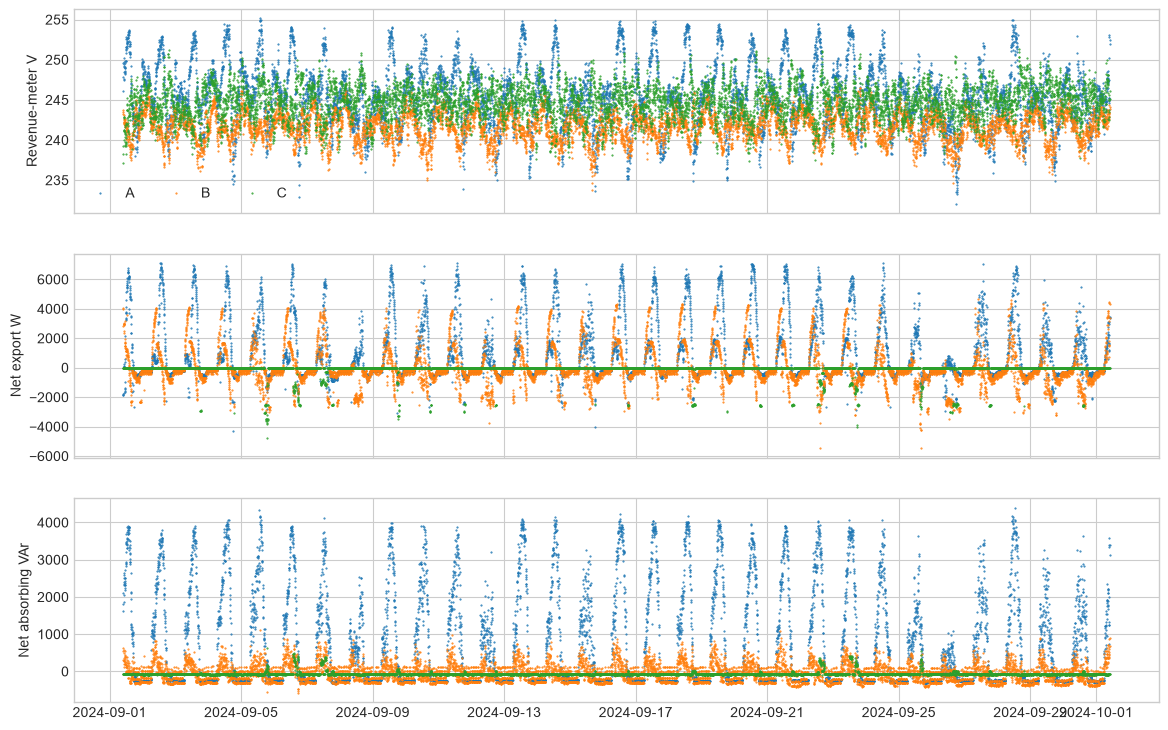

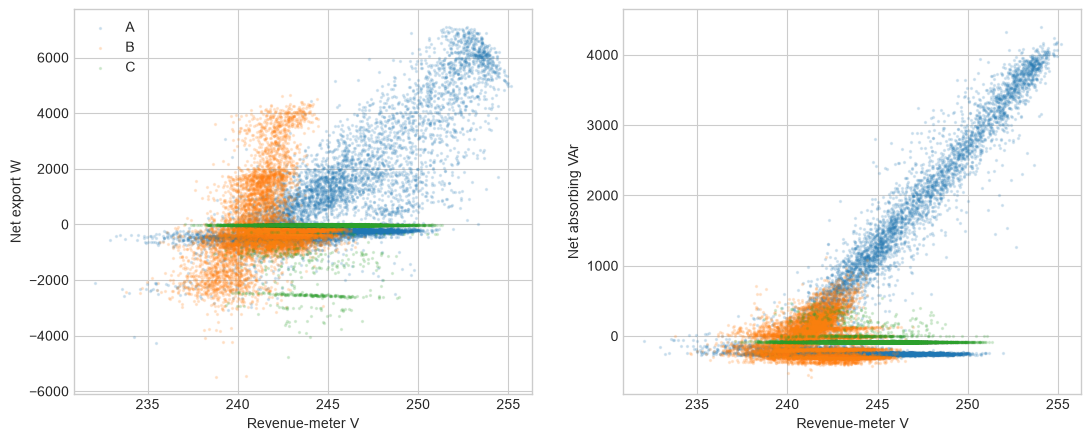

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for phase, g in sample.groupby('phase'):
    axes[0].plot(g.timestamp_local, g.voltage_v.where(g.voltage_physical_ok), '.', ms=1, label=phase)
    axes[1].plot(g.timestamp_local, g.p_export_w, '.', ms=1, label=phase)
    axes[2].plot(g.timestamp_local, g.q_absorbing_var, '.', ms=1, label=phase)
axes[0].set_ylabel('Revenue-meter V'); axes[1].set_ylabel('Net export W'); axes[2].set_ylabel('Net absorbing VAr')
axes[0].legend(ncol=3); plt.show()

valid = sample[sample.voltage_physical_ok & sample.p_export_w.notna() & sample.q_absorbing_var.notna()]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for phase, g in valid.groupby('phase'):
    axes[0].scatter(g.voltage_v, g.p_export_w, s=2, alpha=.15, label=phase)
    axes[1].scatter(g.voltage_v, g.q_absorbing_var, s=2, alpha=.15, label=phase)
axes[0].set(xlabel='Revenue-meter V', ylabel='Net export W'); axes[1].set(xlabel='Revenue-meter V', ylabel='Net absorbing VAr')
axes[0].legend(); plt.show()

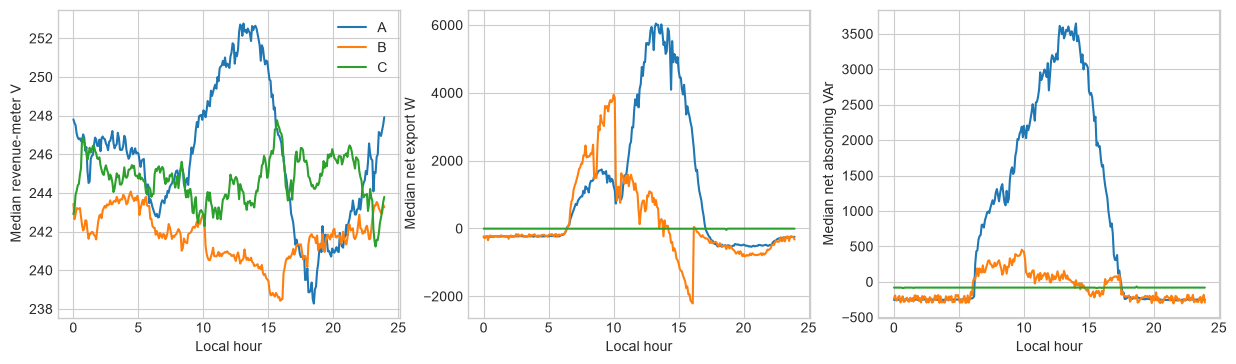

,rows,p_null,q_null,current_null,voltage_zero
phase,,,,,
A,8640,0,0,0,0
B,8640,0,0,0,0
C,8640,0,0,0,0


In [7]:
daily = (sample.assign(local_hour=sample.timestamp_local.dt.hour + sample.timestamp_local.dt.minute/60)
         .groupby(['phase','local_hour'])[['voltage_v','p_export_w','q_absorbing_var']].median().reset_index())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for phase, g in daily.groupby('phase'):
    for ax, col in zip(axes, ['voltage_v','p_export_w','q_absorbing_var']): ax.plot(g.local_hour, g[col], label=phase)
axes[0].set_ylabel('Median revenue-meter V'); axes[1].set_ylabel('Median net export W'); axes[2].set_ylabel('Median net absorbing VAr')
for ax in axes: ax.set_xlabel('Local hour')
axes[0].legend(); plt.show()

quality = sample.groupby('phase').agg(
    rows=('serial','size'), p_null=('p_export_w',lambda x:x.isna().sum()),
    q_null=('q_absorbing_var',lambda x:x.isna().sum()),
    current_null=('current_a',lambda x:x.isna().sum()),
    voltage_zero=('voltage_v',lambda x:(x<=0).sum()))
display(quality)

## Sign, metadata, duplicate provenance and timezone checks

In [8]:
sample['local_period'] = pd.cut(sample.timestamp_local.dt.hour, [-1,5,9,15,19,24], labels=['night','morning','midday','evening','late'])
display(sample.groupby(['local_period','phase'], observed=True)[['active_power_raw_w','p_export_w','reactive_power_raw_var','q_absorbing_var']].median())
print('Working signs only — active export sign:', config.assumptions.active_export_sign,
      '; reactive absorbing sign:', config.assumptions.reactive_absorbing_sign)

metadata = con.execute(f'''SELECT * FROM read_parquet({sql_string(metadata_output_path(config))}) WHERE cast(serial as varchar)=?''', [str(SERIAL)]).fetchdf()
display(metadata)
audit = duplicate_audit_path(config, full_scope)
if audit.is_file():
    display(con.execute(f'''SELECT * FROM read_parquet({sql_string(audit)}) WHERE cast(serial as varchar)=? ORDER BY row_count DESC LIMIT 25''', [str(SERIAL)]).fetchdf())

display(con.execute('''SELECT timestamp_utc, timestamp_local,
    date_diff('minute', cast(timestamp_utc AS TIMESTAMP), timestamp_local) utc_offset_minutes
    FROM canonical WHERE cast(serial as varchar)=? ORDER BY timestamp_utc LIMIT 20''', [str(SERIAL)]).fetchdf())
print('Close connection when finished: con.close()')

active_power_raw_w   p_export_w  reactive_power_raw_var  \
local_period phase                                                            
night        A              234.839111  -234.839111             -250.154700   
             B              224.628708  -224.628708             -255.259888   
             C                5.105198    -5.105198              -81.683170   
morning      A             -862.778442   862.778442             1097.617550   
             B            -1363.087890  1363.087890              229.733900   
             C                5.105198    -5.105198              -81.683170   
midday       A            -3527.691725  3527.691725             2713.412665   
             B              163.366333  -163.366333               15.315594   
             C                5.105198    -5.105198              -81.683170   
evening      A              428.836600  -428.836600             -153.155945   
             B              454.362600  -454.362600             -150.603340   
             C                5.105198    -5.105198              -81.683170   
late         A              439.047028  -439.047028             -255.259888   
             B              592.202942  -592.202942             -245.049500   
             C                5.105198    -5.105198              -81.683170   

                    q_absorbing_var  
local_period phase                   
night        A          -250.154700  
             B          -255.259888  
             C           -81.683170  
morning      A          1097.617550  
             B           229.733900  
             C           -81.683170  
midday       A          2713.412665  
             B            15.315594  
             C           -81.683170  
evening      A          -153.155945  
             B          -150.603340  
             C           -81.683170  
late         A          -255.259888  
             B          -245.049500  
             C           -81.683170

Working signs only — active export sign: -1 ; reactive absorbing sign: 1


,serial,controlled_load,der_type,install_phase_count,approved_capacity_kw,solar_capacity_kw,solar_manufacturer,solar_model,battery_kwh,battery_manufacturer,battery_model,battery_inverter_capacity_kw,solar_install_year,battery_install_year,zone_external_id,sub_external_id,sub_lat,sub_long,fy26_evm_test,has_battery,analysis_cohort,s_rated_kva,s_rated_source
0,810584444,No,Solar,3,20,16.799999,SolarEdge Technologies Ltd,SE8250H (AS4777-2 2020),0.0,0,0,0.0,2023,NaN,2652,2730,-33.673398,151.29294,0,False,solar_only,NaN,unavailable


,serial,measure_time,phase,row_count,payload_variant_count,source_file_count,duplicate_class
0,810584444,2025-03-11 03:25:00,C,16,1,1,identical_duplicate
1,810584444,2025-03-11 05:45:00,C,16,1,1,identical_duplicate
2,810584444,2025-03-11 08:15:00,B,16,1,1,identical_duplicate
3,810584444,2025-03-11 05:25:00,C,16,1,1,identical_duplicate
4,810584444,2025-03-11 04:45:00,B,16,1,1,identical_duplicate
5,810584444,2025-03-11 05:05:00,A,16,1,1,identical_duplicate
6,810584444,2025-03-11 06:50:00,B,16,1,1,identical_duplicate
7,810584444,2025-03-11 06:35:00,C,16,1,1,identical_duplicate
8,810584444,2025-03-11 07:30:00,C,16,1,1,identical_duplicate
9,810584444,2025-03-11 05:30:00,C,16,1,1,identical_duplicate


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,timestamp_utc,timestamp_local,utc_offset_minutes
0,2024-08-01 00:00:00+00:00,2024-08-01 10:00:00,600
1,2024-08-01 00:00:00+00:00,2024-08-01 10:00:00,600
2,2024-08-01 00:00:00+00:00,2024-08-01 10:00:00,600
3,2024-08-01 00:05:00+00:00,2024-08-01 10:05:00,600
4,2024-08-01 00:05:00+00:00,2024-08-01 10:05:00,600
5,2024-08-01 00:05:00+00:00,2024-08-01 10:05:00,600
6,2024-08-01 00:10:00+00:00,2024-08-01 10:10:00,600
7,2024-08-01 00:10:00+00:00,2024-08-01 10:10:00,600
8,2024-08-01 00:10:00+00:00,2024-08-01 10:10:00,600
9,2024-08-01 00:15:00+00:00,2024-08-01 10:15:00,600


Close connection when finished: con.close()


# Scratch book

In [9]:
sample

,serial,timestamp_utc,timestamp_local,phase,voltage_v,current_a,active_power_raw_w,reactive_power_raw_var,p_export_w,q_absorbing_var,q_generator_var,source_month,source_file,duplicate_count,duplicate_source_file_count,duplicate_status,row_has_null_measurement,voltage_physical_ok,metadata_available,analysis_cohort,install_phase_count,month_utc,site_bucket,year_utc,local_period
0,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,A,249.595062,11.310812,1837.871220,2113.552000,-1837.871220,2113.552000,-2113.552000,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,midday
1,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,B,243.720291,16.635548,-4017.790770,638.149700,4017.790770,638.149700,-638.149700,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,midday
2,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,C,238.226868,0.328781,0.000000,-76.577970,-0.000000,-76.577970,76.577970,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,midday
3,810584444,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,A,247.791400,10.581449,1863.397220,1812.345210,-1863.397220,1812.345210,-1812.345210,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,midday
4,810584444,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,B,243.534775,16.767816,-4058.632320,551.361400,4058.632320,551.361400,-551.361400,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,midday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,810584444,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,B,244.153168,14.352979,-3374.536000,903.620056,3374.536000,903.620056,-903.620056,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,morning
25916,810584444,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,C,245.152908,0.340118,5.105198,-81.683170,-5.105198,-81.683170,81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,morning
25917,810584444,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,A,252.429367,19.114630,-3425.588000,3394.956540,3425.588000,3394.956540,-3394.956540,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,morning
25918,810584444,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,B,243.916122,18.026253,-4344.523440,668.780945,4344.523440,668.780945,-668.780945,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024,morning


In [10]:
CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
MONTH = '2024-09'
SERIAL = None
DATE_FROM = None  # local date, e.g. '2025-04-10'
DATE_TO = None    # local date, exclusive
PHASES = ['A', 'B', 'C']
MAX_ROWS = 100_000

config = load_config(CONFIG_PATH, check_inputs=False)
full_scope = config.scope(None, None)
canonical_dir = canonical_output_path(config, full_scope)
assert canonical_dir.is_dir(), f'Run notebook 01 first: {canonical_dir}'
canonical_glob = str(canonical_dir / '**' / '*.parquet')
con = duckdb.connect()
con.execute(f"SET memory_limit='{config.processing.memory_limit}'")
con.execute(f"SET threads={min(config.processing.threads, 4)}")
con.execute("SET TimeZone='UTC'")
con.execute(f"CREATE VIEW canonical AS SELECT * FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning=true)")
print('Canonical source:', canonical_dir)

Canonical source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\canonical_phase


In [11]:
voltage_high_sites = con.execute("""
    SELECT CAST(serial AS VARCHAR) AS serial,
           COUNT(*) AS n_rows,
           MIN(timestamp_local) AS first_seen,
           MAX(timestamp_local) AS last_seen
    FROM canonical
    WHERE year_utc = ? AND month_utc = ?
      AND voltage_v > 253
    GROUP BY serial
    ORDER BY n_rows DESC
""", [year, month]).fetchdf()

display(voltage_high_sites)

,serial,n_rows,first_seen,last_seen
0,810973387,3044,2024-09-01 10:25:00,2024-09-20 09:50:00
1,810787015,2771,2024-09-01 10:00:00,2024-09-20 09:35:00
2,810961976,2558,2024-09-01 11:00:00,2024-09-20 09:30:00
3,810578490,2484,2024-09-01 10:30:00,2024-10-01 09:55:00
4,810508901,2103,2024-09-01 11:30:00,2024-09-30 15:20:00
...,...,...,...,...
221,810886469,1,2024-09-11 13:05:00,2024-09-11 13:05:00
222,810886892,1,2024-09-16 12:20:00,2024-09-16 12:20:00
223,810963647,1,2024-09-17 19:20:00,2024-09-17 19:20:00
224,811027904,1,2024-09-15 12:40:00,2024-09-15 12:40:00


In [12]:
year, month = map(int, MONTH.split('-'))
overview = con.execute('''
    SELECT count(*) n_rows, count(DISTINCT serial) n_sites,
           min(timestamp_local) first_local, max(timestamp_local) last_local,
           count_if(NOT voltage_physical_ok) invalid_voltage_rows,
           count_if(p_export_w IS NULL) null_p_rows,
           count_if(q_absorbing_var IS NULL) null_q_rows,
           count_if(NOT metadata_available) rows_without_metadata
    FROM canonical WHERE year_utc=? AND month_utc=?
''', [year, month]).fetchdf()
display(overview)

site_choices = con.execute('''
    SELECT serial, analysis_cohort, install_phase_count, count(*) n_rows,
           count_if(p_export_w IS NOT NULL) n_power_rows
    FROM canonical WHERE year_utc=? AND month_utc=?
    GROUP BY ALL ORDER BY n_power_rows DESC LIMIT 50
''', [year, month]).fetchdf()
display(site_choices.head(20))
if SERIAL is None:
    SERIAL = str(site_choices.iloc[0]['serial'])
print('Selected serial:', SERIAL)

,n_rows,n_sites,first_local,last_local,invalid_voltage_rows,null_p_rows,null_q_rows,rows_without_metadata
0,23219460,1327,2024-09-01 10:00:00,2024-10-01 09:55:00,140526.0,5236953.0,5236953.0,1146705.0


,serial,analysis_cohort,install_phase_count,n_rows,n_power_rows
0,810778228,solar_only,2,25920,25920.0
1,811282786,NaN,<NA>,25920,25920.0
2,810787137,NaN,<NA>,25920,25920.0
3,810961875,solar_only,1,25920,25920.0
4,810973212,solar_only,1,25920,25920.0
5,810662559,solar_only,3,25920,25920.0
6,810211217,solar_only,1,25920,25920.0
7,810873766,solar_battery,3,25920,25920.0
8,810232063,solar_battery,3,25920,25920.0
9,811017250,solar_battery,1,25920,25920.0


Selected serial: 810778228
